<a href="https://colab.research.google.com/github/wongihun/new-one/blob/main/lstm_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install Korpora
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
!ls
%cd Mecab-ko-for-Google-Colab/
!bash install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
Mecab-ko-for-Google-Colab  sample_data
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
  Using cached konlpy-0.6.0-py2.py3-none-any.whl.metadata (1.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 45.4 MB/s eta 0:00:00
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-06-08 10:08:42--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.25, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-06-08 10:08:42 ERROR 404: Not Found.

Done
Unpacking mecab-0.996-ko-0.9.2.tar.gz.......
Done
Change Directory to 

In [ ]:
import zipfile
import json
import random
import re
import numpy as np

from konlpy.tag import Mecab

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

from tensorflow.keras.models import Model

import matplotlib.pyplot as plt

In [ ]:
# json 파일의 데이터 추출 및 데이터 형식 변환
# json → list 데이터
questions = []
answers = []

#파일(zip) 읽기
with zipfile.ZipFile(
    "/content/TL_02. FACEBOOK.zip",
    "r"
) as z:

    for file_name in z.namelist():
        if not file_name.endswith(".json"):
            continue
        data = json.loads(
            z.read(file_name)
            .decode("utf-8")
        )

        # 데이터의 대화 원본 데이터 추출
        for dialog in data["info"]:
            lines = dialog["annotations"]["lines"]
            for i in range(len(lines)-1):
                if (
                    lines[i]["speaker"]["id"]
                    !=
                    lines[i+1]["speaker"]["id"]
                ):
                    q = lines[i]["norm_text"].strip()
                    a = lines[i+1]["norm_text"].strip()
                    if q and a:
                        questions.append(q)
                        answers.append(a)

print(len(questions))

103306


In [ ]:
#일부 데이터 : 35000 개만 사용(랜덤)
sample_size = 35000

data = list(
    zip(
        questions,
        answers
    )
)

random.shuffle(data)

data = data[:sample_size]

questions = [
    q for q,a in data
]

answers = [
    a for q,a in data
]

In [ ]:
#kiwi 라이브러리 응용하는 경우
#둘중 하나만 사용할 것
kiwi = Kiwi()

def preprocess(text):

    text = re.sub(
        r"[^가-힣0-9 ]",
        " ",
        text
    )

    tokens = []

    for token in kiwi.tokenize(text):

        tokens.append(
            token.form
        )

    return " ".join(tokens)

NameError: name 'Kiwi' is not defined

In [ ]:
#mecab 버전
#둘중 하나만 사용할 것
mecab = Mecab()

def preprocess(text):

    text = re.sub(
        r"[^가-힣0-9 ]",
        " ",
        text
    )

    return " ".join(
        word
        for word, tag in mecab.pos(text)
        if not tag.startswith("S")
    )

In [ ]:
#전처리
questions = [
    preprocess(q)
    for q in questions
]

answers = [
    preprocess(a)
    for a in answers
]

In [ ]:
answers = [
    "<START> " + a + " <END>"
    for a in answers
]

In [ ]:
tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(
    questions + answers
)

vocab_size = min(
    10000,
    len(tokenizer.word_index)+1
)

print(
    "어휘 수:",
    vocab_size
)

어휘 수: 10000


In [ ]:
encoder_input_seq = tokenizer.texts_to_sequences(
    questions
)

decoder_input_texts = []
decoder_target_texts = []

for answer in answers:

    words = answer.split()

    decoder_input_texts.append(
        " ".join(words[:-1])
    )

    decoder_target_texts.append(
        " ".join(words[1:])
    )

In [ ]:
decoder_input_seq = tokenizer.texts_to_sequences(
    decoder_input_texts
)

decoder_target_seq = tokenizer.texts_to_sequences(
    decoder_target_texts
)

In [ ]:
max_q_len = max(
    len(x)
    for x in encoder_input_seq
)

max_a_len = max(
    len(x)
    for x in decoder_input_seq
)

In [ ]:
encoder_input = pad_sequences(
    encoder_input_seq,
    maxlen=max_q_len,
    padding="post"
)

decoder_input = pad_sequences(
    decoder_input_seq,
    maxlen=max_a_len,
    padding="post"
)

decoder_target = pad_sequences(
    decoder_target_seq,
    maxlen=max_a_len,
    padding="post"
)

decoder_target = np.expand_dims(
    decoder_target,
    axis=-1
)

In [ ]:
encoder_inputs = Input(
    shape=(max_q_len,)
)

encoder_embedding = Embedding(
    vocab_size,
    128,
)(
    encoder_inputs
)

encoder_outputs, state_h, state_c = LSTM(
    512,
    return_state=True
)(
    encoder_embedding
)

encoder_states = [
    state_h,
    state_c
]

In [ ]:
decoder_inputs = Input(
    shape=(max_a_len,)
)

decoder_embedding_layer = Embedding(
    vocab_size,
    128,
)

decoder_embedding = decoder_embedding_layer(
    decoder_inputs
)

decoder_lstm = LSTM(
    512,
    return_sequences=True,
    return_state=True
)

decoder_outputs, _, _ = decoder_lstm(
    decoder_embedding,
    initial_state=encoder_states
)

decoder_dense = Dense(
    vocab_size,
    activation="softmax"
)

decoder_outputs = decoder_dense(
    decoder_outputs
)

In [ ]:
model = Model(
    [encoder_inputs, decoder_inputs],
    decoder_outputs
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 44)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 52)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 44, 128)   │  1,280,000 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 52, 128)   │  1,280,000 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ [(None, 512),     │  1,312,768 │ embedding_4[0][0] │
│                     │ (None, 512),      │            │                   │
│                     │ (None, 512)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_5 (LSTM)       │ [(None, 52, 512), │  1,312,768 │ embedding_5[0][0… │
│                     │ (None, 512),      │            │ lstm_4[0][1],     │
│                     │ (None, 512)]      │            │ lstm_4[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 52, 10000) │  5,130,000 │ lstm_5[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,315,536 (39.35 MB)

 Trainable params: 10,315,536 (39.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 62s 121ms/step - accuracy: 0.8243 - loss: 1.2653 - val_accuracy: 0.8329 - val_loss: 1.0857
Epoch 2/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 81s 119ms/step - accuracy: 0.8406 - loss: 1.0305 - val_accuracy: 0.8447 - val_loss: 1.0014
Epoch 3/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 82s 119ms/step - accuracy: 0.8489 - loss: 0.9623 - val_accuracy: 0.8496 - val_loss: 0.9582
Epoch 4/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 58s 118ms/step - accuracy: 0.8527 - loss: 0.9187 - val_accuracy: 0.8520 - val_loss: 0.9354
Epoch 5/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 83s 120ms/step - accuracy: 0.8549 - loss: 0.8875 - val_accuracy: 0.8532 - val_loss: 0.9221
Epoch 6/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 58s 119ms/step - accuracy: 0.8565 - loss: 0.8611 - val_accuracy: 0.8541 - val_loss: 0.9121
Epoch 7/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 59s 119ms/step - accuracy: 0.8580 - loss: 0.8374 - val_accuracy: 0.8551 - val_loss: 0.9088
Epoch 8/10
493/493 ━━━━━━━━━━━━━━━━━━━━ 59s 119ms/step - accuracy: 0.8593 - loss: 0

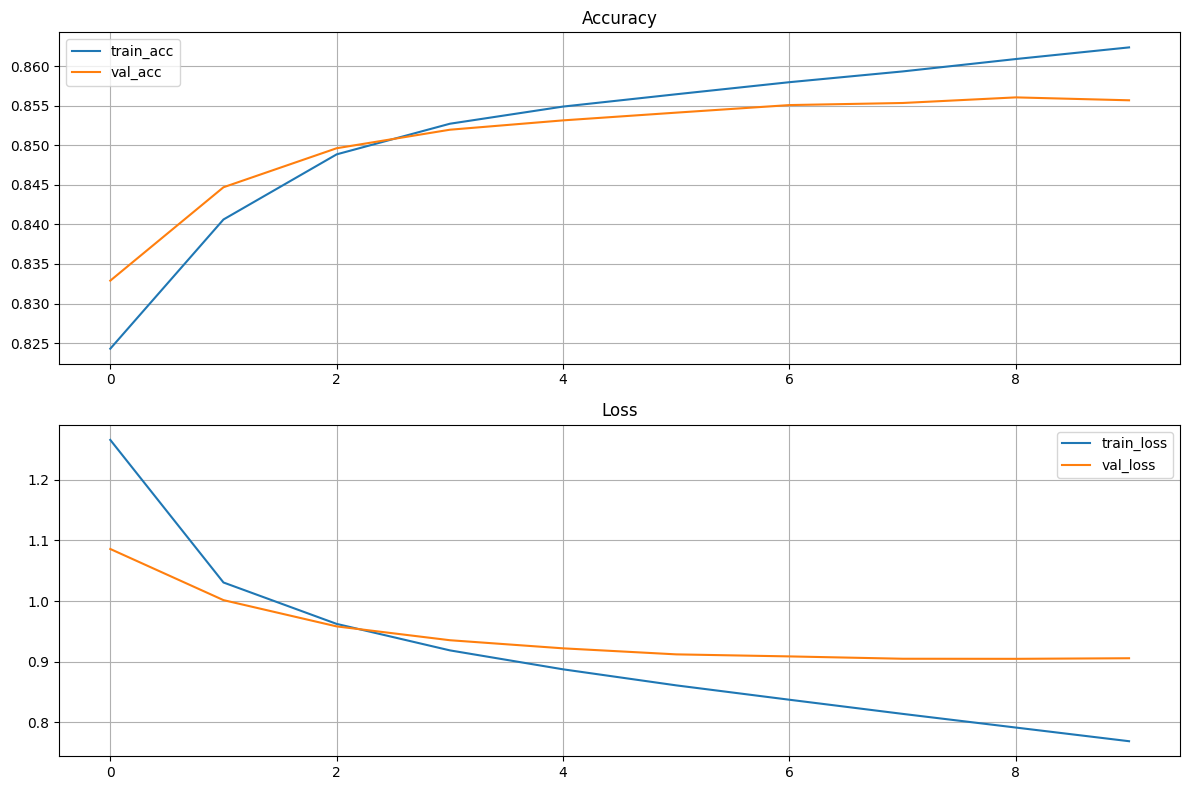

In [ ]:
plt.figure(figsize=(12,8))

# 정확도
plt.subplot(2,1,1)

plt.plot(
    history.history["accuracy"],
    label="train_acc"
)

plt.plot(
    history.history["val_accuracy"],
    label="val_acc"
)

plt.title("Accuracy")
plt.legend()
plt.grid()

# 손실
plt.subplot(2,1,2)

plt.plot(
    history.history["loss"],
    label="train_loss"
)

plt.plot(
    history.history["val_loss"],
    label="val_loss"
)

plt.title("Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.show()

In [ ]:
model.save("/content/facebook_seq2seq.keras")

In [ ]:
model = load_model(
    "facebook_seq2seq.keras"
)

In [ ]:
encoder_model = Model(
    encoder_inputs,
    encoder_states
)

In [ ]:
decoder_state_input_h = Input(
    shape=(512,)
)

decoder_state_input_c = Input(
    shape=(512,)
)

decoder_states_inputs = [
    decoder_state_input_h,
    decoder_state_input_c
]

decoder_embedding2 = decoder_embedding_layer(
    decoder_inputs
)

decoder_outputs2, state_h2, state_c2 = decoder_lstm(
    decoder_embedding2,
    initial_state=decoder_states_inputs
)

decoder_states2 = [
    state_h2,
    state_c2
]

decoder_outputs2 = decoder_dense(
    decoder_outputs2
)

decoder_model = Model(
    [decoder_inputs] + decoder_states_inputs,
    [decoder_outputs2] + decoder_states2
)

In [ ]:
index_to_word = {}

for word, idx in tokenizer.word_index.items():

    if idx < vocab_size:
        index_to_word[idx] = word

start_token = tokenizer.word_index["start"]
end_token = tokenizer.word_index["end"]

In [ ]:
def predict_chat(text):

    text = preprocess(text)

    seq = tokenizer.texts_to_sequences(
        [text]
    )

    seq = pad_sequences(
        seq,
        maxlen=max_q_len,
        padding="post"
    )

    states = encoder_model.predict(
        seq,
        verbose=0
    )

    target_seq = np.array(
        [[start_token]]
    )

    result = []

    while True:

        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states,
            verbose=0
        )
        temperature = 0.1
        probs = output_tokens[0, -1, :]

        probs = np.log(probs + 1e-10) / temperature
        probs = np.exp(probs)
        probs = probs / np.sum(probs)

        sampled_token = np.random.choice(
            len(probs),
            p=probs
        )

        if (
            sampled_token == end_token
            or
            len(result) > max_a_len
        ):
            break

        word = index_to_word.get(
            sampled_token,
            ""
        )

        if word in [
            "start",
            "end",
            "<OOV>"
        ]:
            continue

        result.append(word)

        target_seq = np.array(
            [[sampled_token]]
        )

        states = [h, c]

    return " ".join(result)

In [ ]:
while True:

    text = input("사용자 : ")

    if text == "종료":
        break

    print(
        "챗봇 :",
        predict_chat(text)
    )

In [ ]:
history.history["accuracy"][-1]
history.history["val_accuracy"][-1]

0.8577143549919128